## Time Series Data in Pandas with Yahoo Finance: Introduction


### Exercise 11: Downsampling and Reindexing Financial Time Series

This version downloads the market data directly from Yahoo Finance instead of reading `aapl_fb.csv`.


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use("seaborn-v0_8")


In [24]:
# Download daily Apple and Meta (formerly Facebook) prices from Yahoo Finance
# End date is exclusive in yfinance.
raw = yf.download(
    ["AAPL", "META"],
    start="2000-01-01",
    end="2026-08-08",
    interval="1d",
    auto_adjust=False,
    progress=False,
    group_by="column",
    multi_level_index=True
)

# The original exercise works with one price column per company.
# Use Yahoo Finance Close prices and rename META -> FB for compatibility
# with the original exercise terminology.
stocks = raw["Close"][["AAPL", "META"]].copy()
stocks = stocks.rename(columns={"META": "FB"})
stocks.index.name = "Date"

stocks.head(30)


Ticker,AAPL,FB
Date,,
2000-01-03,0.999442,NaN
2000-01-04,0.915179,NaN
2000-01-05,0.928571,NaN
2000-01-06,0.848214,NaN
2000-01-07,0.888393,NaN
2000-01-10,0.872768,NaN
2000-01-11,0.828125,NaN
2000-01-12,0.778460,NaN
2000-01-13,0.863839,NaN


In [25]:
# run the cell!
stocks.head(30)

Ticker,AAPL,FB
Date,,
2000-01-03,0.999442,NaN
2000-01-04,0.915179,NaN
2000-01-05,0.928571,NaN
2000-01-06,0.848214,NaN
2000-01-07,0.888393,NaN
2000-01-10,0.872768,NaN
2000-01-11,0.828125,NaN
2000-01-12,0.778460,NaN
2000-01-13,0.863839,NaN


In [26]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6689 entries, 2000-01-03 to 2026-08-07
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    6689 non-null   float64
 1   FB      3575 non-null   float64
dtypes: float64(2)
memory usage: 156.8 KB


98. __Change Frequency__ of stocks to __monthly__ ("Downsampling") and display the __last__ traded stock price per month! (Hint: The Index should show the last calender day of each month) <br>
What is the __last__ traded price for __Facebook__ in __March 2015__?

In [27]:
# Downsample daily prices to month-end and keep the final traded price
stocks_monthly_last = stocks.resample("ME").last()
display(stocks_monthly_last.head())


Ticker,AAPL,FB
Date,,
2000-01-31,0.926339,NaN
2000-02-29,1.023438,NaN
2000-03-31,1.212612,NaN
2000-04-30,1.107701,NaN
2000-05-31,0.750000,NaN


In [28]:
# Last traded Facebook/Meta price in March 2015
facebook_march_2015_price = stocks_monthly_last.loc["2015-03-31", "FB"]
print(f"Yahoo Finance: last META (FB) close in March 2015 = {facebook_march_2015_price:.2f}")


Yahoo Finance: last META (FB) close in March 2015 = 82.22


> **Note:** The Yahoo Finance result may differ from the original course answer because the source data and historical corporate-action adjustments can differ.


99. Perform the __same__ operation as in __exercise 98__. Instead of displaying the __last day__ of the respective period (e.g. 2015-01-31), display the __period__ (e.g. 2015-01) in the __Index__!

In [29]:
# Convert the month-end DatetimeIndex to a monthly PeriodIndex
stocks_monthly_period_last = stocks.resample("ME").last()
stocks_monthly_period_last.index = stocks_monthly_period_last.index.to_period("M")
display(stocks_monthly_period_last.head())


Ticker,AAPL,FB
Date,,
2000-01,0.926339,NaN
2000-02,1.023438,NaN
2000-03,1.212612,NaN
2000-04,1.107701,NaN
2000-05,0.750000,NaN


100. Calculate __monthly average/mean stock prices__ and save the new DataFrame in the variable __stocks_m__!

In [30]:
stocks_m = stocks.resample("ME").mean()
display(stocks_m.head())


Ticker,AAPL,FB
Date,,
2000-01-31,0.922852,NaN
2000-02-29,0.996770,NaN
2000-03-31,1.147346,NaN
2000-04-30,1.099154,NaN
2000-05-31,0.900093,NaN


What was the average stock price for __Apple__ in __April 2015__?

In [31]:
# Average Apple price in April 2015 using Yahoo Finance data
apple_april_2015 = stocks_m.loc["2015-04-30", "AAPL"]
print(f"Yahoo Finance: average AAPL close in April 2015 = {apple_april_2015:.2f}")


Yahoo Finance: average AAPL close in April 2015 = 31.82


> The result above is calculated directly from the Yahoo Finance daily closing-price series. It does not need to match the original static-file answer exactly.


101. __Plot__ __stocks__ and __stocks_m__ (figsize = (12 , 8) and compare!

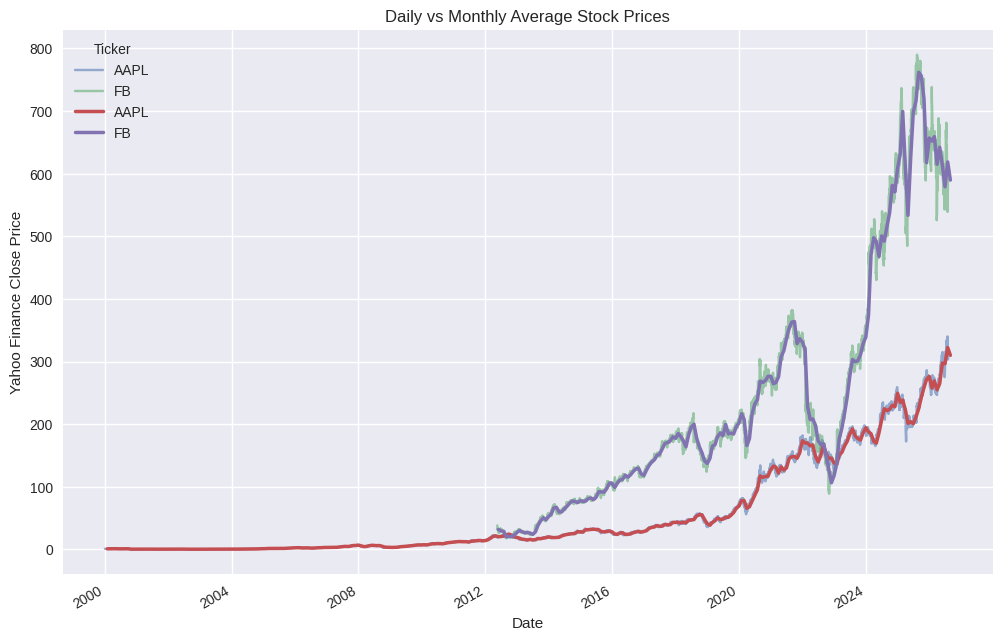

In [32]:
ax = stocks.plot(figsize=(12, 8), alpha=0.55, title="Daily vs Monthly Average Stock Prices")
stocks_m.plot(ax=ax, linewidth=2.5)
ax.set_xlabel("Date")
ax.set_ylabel("Yahoo Finance Close Price")
plt.show()


102. __Downsample__ stocks to __weekly__ frequency, showing prices on __Fridays__!
Whast was __Facebook´s__ stock price on the __fourth Friday__ in __January 2015__?

In [33]:
# Downsample to weekly frequency, labeling each observation on Friday.
# .last() keeps the final available trading observation in each Friday-ending week.
stocks_weekly_friday = stocks.resample("W-FRI").last()
display(stocks_weekly_friday.head())


Ticker,AAPL,FB
Date,,
2000-01-07,0.888393,NaN
2000-01-14,0.896763,NaN
2000-01-21,0.993862,NaN
2000-01-28,0.907366,NaN
2000-02-04,0.964286,NaN


In [34]:
# Fourth Friday in January 2015
jan_fridays = pd.date_range("2015-01-01", "2015-01-31", freq="W-FRI")
fourth_friday_jan_2015 = jan_fridays[3]

facebook_price_fourth_friday = stocks_weekly_friday.loc[fourth_friday_jan_2015, "FB"]
print("Fourth Friday:", fourth_friday_jan_2015.date())
print(f"Yahoo Finance META (FB) close used for that week = {facebook_price_fourth_friday:.2f}")


Fourth Friday: 2015-01-23
Yahoo Finance META (FB) close used for that week = 77.83


> The value above comes from Yahoo Finance. The original notebook's static-file answer is intentionally not hard-coded.


In [35]:
# run the cell! -> January 2015 prices
stocks.loc["2015-01"]

Ticker,AAPL,FB
Date,,
2015-01-02,27.332500,78.449997
2015-01-05,26.562500,77.190002
2015-01-06,26.565001,76.150002
2015-01-07,26.937500,76.150002
2015-01-08,27.972500,78.180000
2015-01-09,28.002501,77.739998
2015-01-12,27.312500,76.720001
2015-01-13,27.555000,76.449997
2015-01-14,27.450001,76.279999


103. __Create__ a __DatetimeIndex__ with all __31 days__ in __January 2015__! __Save__ the Index in the variable __alldays_jan__

In [36]:
alldays_jan = pd.date_range(start="2015-01-01", end="2015-01-31", freq="D")
display(alldays_jan)


DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10', '2015-01-11', '2015-01-12',
               '2015-01-13', '2015-01-14', '2015-01-15', '2015-01-16',
               '2015-01-17', '2015-01-18', '2015-01-19', '2015-01-20',
               '2015-01-21', '2015-01-22', '2015-01-23', '2015-01-24',
               '2015-01-25', '2015-01-26', '2015-01-27', '2015-01-28',
               '2015-01-29', '2015-01-30', '2015-01-31'],
              dtype='datetime64[ns]', freq='D')

In [37]:
# run the cell!
alldays_jan

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09', '2015-01-10', '2015-01-11', '2015-01-12',
               '2015-01-13', '2015-01-14', '2015-01-15', '2015-01-16',
               '2015-01-17', '2015-01-18', '2015-01-19', '2015-01-20',
               '2015-01-21', '2015-01-22', '2015-01-23', '2015-01-24',
               '2015-01-25', '2015-01-26', '2015-01-27', '2015-01-28',
               '2015-01-29', '2015-01-30', '2015-01-31'],
              dtype='datetime64[ns]', freq='D')

104. __Reindex stocks__ by __alldays_jan__ and __forward fill__ any NaN-Values!

In [38]:
# Reindex January 2015 to every calendar day and carry the last known market price forward.
stocks_reindexed_ffill = stocks.loc["2015-01"].reindex(alldays_jan).ffill()
display(stocks_reindexed_ffill.head(10))


Ticker,AAPL,FB
2015-01-01,NaN,NaN
2015-01-02,27.332500,78.449997
2015-01-03,27.332500,78.449997
2015-01-04,27.332500,78.449997
2015-01-05,26.562500,77.190002
2015-01-06,26.565001,76.150002
2015-01-07,26.937500,76.150002
2015-01-08,27.972500,78.180000
2015-01-09,28.002501,77.739998
2015-01-10,28.002501,77.739998


## Yahoo Finance Version — Key Idea

Yahoo Finance supplies the **daily observations**. Pandas performs the time-series transformations:

- `resample("ME").last()` → final trading observation of each month
- `resample("ME").mean()` → monthly average
- `resample("W-FRI").last()` → Friday-ending weekly series
- `to_period("M")` → monthly PeriodIndex
- `reindex(...).ffill()` → calendar-day index with the previous market observation carried forward
